In [ ]:
# Be sure to do the following before trying this script (this will change depending on operating system):
# Step 1. Create a Python virtual environment in a folder (Google how to do this on your operating system)
# Step 2. Install the packages from requirements.txt First open a command window in the working folder, then make sure you have loaded
#         the virtual environment (the start of the line will read (.venv) ). Then run your system's version of "pip install requirements.txt"
# Once these are both done then you will be able to run this. You may have to restart the Jupyter notebook instance. Sometimes it will tell you don't
# have a package installed when you know for a fact you do--just close the Jupyter notebook instance from your terminal (CTRL-C) and restart it.

In [1]:
import pandas as pd
import numpy as np
%matplotlib widget
# aka import ipympl
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import statsmodels.api as sm
from collections import defaultdict
import json
import seaborn as sns
from collections import defaultdict
from io import StringIO
import requests
import time

In [2]:
# This script is best run in the background because it takes approximately 15 minutes to run.
# It's a lot of data you're pulling! 

# ----------------------- RECORD DATES ----------------------- #
thom_temp_start_of_record = "2019-08-02T00:00:00Z"             #
thom_disch_start_of_record = "1990-10-01T00:00:00Z"            #
thom_id = "USGS-01184000"                                      #
                                                               #
had_temp_start_of_record = "2010-09-09T00:00:00Z"              #
had_disch_start_of_record = "2008-12-05T00:00:00Z"             #
haddam_id = "USGS-01193050"                                    #
                                                               #
hol_disch_start_of_record = "2002-11-02T00:00:00Z"             #
hol_id = "USGS-01172010"                                       #

mont_disch_start_of_record = "1993-04-18T00:00:00Z"
mont_id = "USGS-01170500"
# ------------------------------------------------------------ #

# Parameter codes:
discharge_code = "00060"
temp_code = "00010"

url_info = {
"base_url": "https://api.waterdata.usgs.gov/ogcapi/v0/collections/continuous/items?f=csv&lang=en-US&limit=50000&properties=monitoring_location_id,parameter_code,time,value,unit_of_measure&skipGeometry=true&offset=0&monitoring_location_id=",
"url_stage2": "&parameter_code=",
"url_stage3": "&time=",
"header": {"X-Api-Key":""} # TODO: YOU MUST PLACE YOUR API KEY FROM USGS INSIDE EMPTY QUOTES.
}                          # TODO: You can sign up at https://api.waterdata.usgs.gov/signup/
                           # TODO: If you use without an API key, you may be rate limited (rate limit is 1hr wait!)

def get_mean_df(site, parameter, start_of_record, url_info): # This function gets all the existing data for a variable and site, and creates a master dataframe with a mean of each day's values
    todaydt = pd.Timestamp.now(tz='UTC').normalize()
    today = todaydt.strftime("%Y-%m-%dT%H:%M:%SZ")

    day_difference = (pd.to_datetime(today[:10]) - pd.to_datetime(start_of_record[:10])).days

    url = f"{url_info["base_url"]}{site}{url_info["url_stage2"]}{parameter}{url_info["url_stage3"]}" # Assemble URL

    dflist = list()
    
    for i in range(0, day_difference, 150): # Loops through every day since start of record to current day in 550 day increments instead of max 1100 to avoid truncated data (max return values are 50,000)
        time.sleep(3)
        date1 = pd.to_datetime(start_of_record) + pd.Timedelta(days=i)
        date2 = date1 + pd.Timedelta(days = 150)
        if date2 > todaydt:
            date2 = todaydt
        
        response = requests.get(f"{url}{date1.strftime("%Y-%m-%dT%H:%M:%SZ")}/{(date2 - pd.Timedelta(minutes=5)).strftime("%Y-%m-%dT%H:%M:%SZ")}", headers=url_info["header"])
        while response.status_code == 429:
            # Check if 'Retry-After' header exists
            if response.headers.get("Retry-After"): # Not sure this code works... but hopefully it's not necessary
                wait_time = int(response.headers.get("Retry-After"))
                print(f"Rate limited. Waiting for {wait_time} seconds...")
                time.sleep(wait_time)
            else:
                time.sleep(60)
            response = requests.get(f"{url}{date1.strftime("%Y-%m-%dT%H:%M:%SZ")}/{(date2 - pd.Timedelta(minutes=5)).strftime("%Y-%m-%dT%H:%M:%SZ")}", headers=url_info["header"])

        if not response.text.strip():
            print(f"Warning: Received empty data from API: {date1}/{date2}, {parameter}, {site}")
            df = pd.DataFrame()
        else:
            df = pd.read_csv(StringIO(response.text), sep=',')

        if "x" in df.columns:
            df.drop(columns=["x"], inplace=True, errors="ignore")
        if "y" in df.columns:
            df.drop(columns=["y"], inplace=True, errors="ignore")
            
        dflist.append(df)
        if date2 == todaydt:
            break

    fulldf = pd.DataFrame()
    fulldf = pd.concat([fulldf] + dflist, ignore_index=True)
    fulldf["time"] = pd.to_datetime(fulldf["time"], utc=True, errors="coerce")
    fulldf["value"] = pd.to_numeric(fulldf["value"], errors="coerce")

    fulldf["time"] = fulldf["time"].dt.tz_convert("US/Eastern")

    fulldf.dropna(inplace=True)
    fulldf.drop_duplicates(inplace=True)
    fulldf.set_index("time", inplace=True)
    fulldf.sort_index(inplace=True)
    if parameter == "00060":
        fulldf = fulldf[fulldf["value"] > 0].copy() # We don't want discharges less than 0, likely unchecked sensor errors

    fulldf = fulldf.resample("D").agg({ # This takes the mean of every day
        'monitoring_location_id': 'first',
        'parameter_code': 'first',
        'value': 'mean',
        'unit_of_measure': 'first'
    })

    fulldf.reset_index(inplace=True)
    fulldf["day_of_year"] = fulldf["time"].dt.day_of_year # Add day of year column
    units = fulldf.at[1,"unit_of_measure"]
    fulldf = fulldf.rename(columns={"value":f"value ({units})", "time":"date"}) # Remove redundant unit_of_measure column and rename value col appropriately
    fulldf.drop(columns=["unit_of_measure"], errors="ignore", inplace=True)
    fulldf.dropna(inplace=True)
    fulldf.drop_duplicates(inplace=True)
    fulldf["date"] = fulldf["date"].dt.tz_localize(None)

    time.sleep(60) # Abundance of caution to avoid timeouts, since this function gets thousands of days of data

    return fulldf

In [3]:
# Core functionality is the cell above. More sites and parameters may be added if desired. 
had_disch_means = get_mean_df(haddam_id, discharge_code, had_disch_start_of_record, url_info)
#If timeout happens, rerun this cell after 60 minutes.

In [4]:
thom_disch_means = get_mean_df(thom_id, discharge_code, thom_disch_start_of_record, url_info)
#If timeout happens, rerun this cell after 60 minutes.

In [5]:
hol_disch_means = get_mean_df(hol_id, discharge_code, hol_disch_start_of_record, url_info)
#If timeout happens, rerun this cell after 60 minutes.

In [6]:
mont_disch_means = get_mean_df(mont_id, discharge_code, mont_disch_start_of_record, url_info)
#If timeout happens, rerun this cell after 60 minutes.

In [7]:
discharge_means = pd.concat([had_disch_means, thom_disch_means, hol_disch_means, mont_disch_means], ignore_index=True)
discharge_means.to_csv("Discharge Means.csv", index=False)

time.sleep(150) # Another abundance of caution thing. Just leaving the script in the background anyway

In [8]:
had_temp_means = get_mean_df(haddam_id, temp_code, had_temp_start_of_record, url_info)
#If timeout happens, rerun this cell after 60 minutes.

In [9]:
thom_temp_means = get_mean_df(thom_id, temp_code, thom_temp_start_of_record, url_info)
#If timeout happens, rerun this cell after 60 minutes.

In [10]:
temp_means = pd.concat([had_temp_means, thom_temp_means], ignore_index=True)
temp_means.to_csv("Temp Means.csv", index=False)

In [11]:
# -----------------------------------------------------------------------------------------------

In [12]:
# Temperature Comparisons:

In [13]:
# Copy to a new DF for this
source = temp_means.copy()

# Let's filter by Middle Haddam's ID
haddamtemps = source[source["monitoring_location_id"] == "USGS-01193050"]
haddamtemps.reset_index(drop=True, inplace=True) #Reset index so it starts from 0
# Let's filter by Thompsonville's ID
thomtemps = source[source["monitoring_location_id"] == "USGS-01184000"]
thomtemps.reset_index(drop=True, inplace=True) #Reset index so dataframe starts from 0

# Filter by their shared dates
shared_thomtemps = thomtemps[thomtemps["date"].isin(haddamtemps["date"])]
shared_thomtemps.reset_index(drop=True, inplace=True)
shared_hadtemps = haddamtemps[haddamtemps["date"].isin(thomtemps["date"])]
shared_hadtemps.reset_index(drop=True, inplace=True)

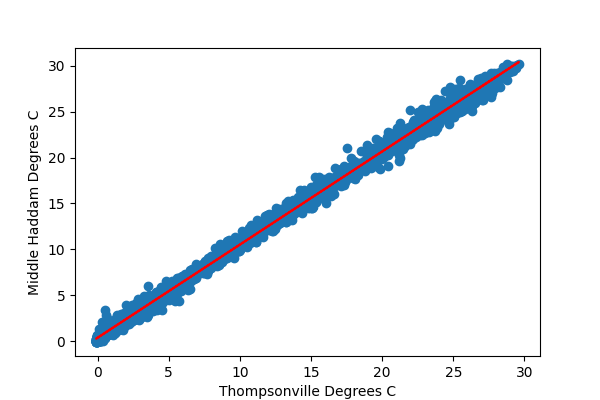

In [14]:
slope, intercept = np.polyfit(shared_thomtemps["value (degC)"], shared_hadtemps["value (degC)"], 1)
plt.figure(figsize=(6,4))
plt.scatter(shared_thomtemps["value (degC)"], shared_hadtemps["value (degC)"])
plt.plot(shared_thomtemps["value (degC)"], slope*np.array(shared_thomtemps["value (degC)"]) + intercept, color='red')
plt.xlabel("Thompsonville Degrees C")
plt.ylabel("Middle Haddam Degrees C")
plt.show()

In [15]:
import statsmodels.api as sm
X = shared_hadtemps["value (degC)"]
X = sm.add_constant(X)
y = shared_thomtemps["value (degC)"]
model = sm.OLS(y, X).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:           value (degC)   R-squared:                       0.997
Model:                            OLS   Adj. R-squared:                  0.997
Method:                 Least Squares   F-statistic:                 7.941e+05
Date:                Wed, 12 Aug 2026   Prob (F-statistic):               0.00
Time:                        13:15:25   Log-Likelihood:                -1961.5
No. Observations:                2527   AIC:                             3927.
Df Residuals:                    2525   BIC:                             3939.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
const           -0.3170      0.018    -17.739   

In [16]:
fig = plt.figure(figsize=(14, 8))
fig = sm.graphics.plot_regress_exog(model, "value (degC)", fig=fig)  

In [17]:
# -----------------------------------------------------------------------------------------------

In [18]:
# Discharge Lag Modeling:

In [19]:
source = discharge_means.copy()

In [20]:
# Get all USGS IDs in the dataframe just cause I'm lazy
locations = source["monitoring_location_id"].unique()

In [21]:
thom = source[source["monitoring_location_id"] == "USGS-01184000"]
thom.reset_index(drop=True, inplace=True)
holyoke = source[source["monitoring_location_id"] == "USGS-01172010"]
holyoke.reset_index(drop=True, inplace=True)
montague = source[source["monitoring_location_id"] == "USGS-01170500"]
montague.reset_index(drop=True, inplace=True)

In [22]:
# Need to remind Pandas that these columns are of type datetime
thom["date"] = pd.to_datetime(thom["date"])
holyoke["date"] = pd.to_datetime(holyoke["date"])
montague["date"] = pd.to_datetime(montague["date"])

# Create and populate a year column from the date column
thom["year"] = thom["date"].dt.year
holyoke["year"] = holyoke["date"].dt.year
montague["year"] = montague["date"].dt.year

In [23]:
# We are concerned right now with the period of time from day 108 to 181 as these are our Shad run dates
trimmed_thom = thom[thom["day_of_year"].between(108, 181, inclusive="both")].copy()
trimmed_holyoke = holyoke[holyoke["day_of_year"].between(108, 181, inclusive="both")].copy()
trimmed_montague = montague[montague["day_of_year"].between(108, 181, inclusive="both")].copy()

# We're going to pivot the dataframes to access the data in an easier way for how we're going to use it
p_thom = trimmed_thom.pivot(index="year", columns="day_of_year", values="value (ft^3/s)")
p_thom.drop(p_thom.index[-1], inplace=True)
p_holyoke = trimmed_holyoke.pivot(index="year", columns="day_of_year", values="value (ft^3/s)")
p_holyoke.drop(p_holyoke.index[-1], inplace=True)
p_montague = trimmed_montague.pivot(index="year", columns="day_of_year", values="value (ft^3/s)")
p_montague.drop(p_montague.index[-1], inplace=True)

In [24]:
# Means for each DOY
thom_means = p_thom.mean(axis=0)
holyoke_means = p_holyoke.mean(axis=0)
montague_means = p_montague.mean(axis=0)

In [25]:
# Calculate anomalies
thom_anoms = (p_thom.copy() - thom_means)/thom_means
holyoke_anoms = (p_holyoke.copy() - holyoke_means)/holyoke_means
montague_anoms = (p_montague.copy() - montague_means)/montague_means

# Transpose DataFrame for more ease of access (columnwise)
m_t = montague_anoms.transpose()
m_t.reset_index(inplace=True)
t_t = thom_anoms.transpose()
t_t.reset_index(inplace=True)
h_t = holyoke_anoms.transpose()
h_t.reset_index(inplace=True)

In [26]:
# For future use
h_t.to_csv("holyoke_t.csv", index=False)
m_t.to_csv("montague_t.csv", index=False)
t_t.to_csv("thompsonville_t.csv", index=False)

In [28]:
# Correlate Montague-Holyoke, and Holyoke-Thompsonville
for year in range(2003, 2026):
    mon_hol_corr = m_t[year].corr(h_t[year])
    hol_thom_corr = h_t[year].corr(t_t[year])
    print(f"Correlation with lag 0, year {year}: {hol_thom_corr}")
    print(f"Correlation with lag 0, year {year}: {mon_hol_corr} \n")
    
    lags = range(-5, 5)
    correlations1 = {}
    correlations2 = {}
    
    for lag in lags:
        shifted_h = h_t[year].shift(lag)
        correlations1[lag] = m_t.iloc[5:-5].loc[:, year].corr(shifted_h.iloc[5:-5])
        shifted_t = t_t[year].shift(lag)
        correlations2[lag] = h_t.iloc[5:-5].loc[:, year].corr(shifted_t.iloc[5:-5])
    
    target_lag1 = max(correlations1, key=correlations1.get)
    target_lag2 = max(correlations2, key=correlations2.get)
    print(f"M-H Highest correlation lag achieved for year {year}: {target_lag1} day(s)")
    print(f"M-H Correlation at lag of {target_lag1} day(s) in {year}: {correlations1[target_lag1]}\n")

    print(f"H-T Highest correlation lag achieved for year {year}: {target_lag2} day(s)")
    print(f"H-T Correlation at lag of {target_lag2} day(s) in {year}: {correlations2[target_lag2]}")
    print("\n --------------------------------------------------------------- \n")

Correlation with lag 0, year 2003: 0.8763357689466595
Correlation with lag 0, year 2003: 0.8933985138071393 

M-H Highest correlation lag achieved for year 2003: 0 day(s)
M-H Correlation at lag of 0 day(s) in 2003: 0.8846241119089892

H-T Highest correlation lag achieved for year 2003: 0 day(s)
H-T Correlation at lag of 0 day(s) in 2003: 0.8626595098993204

 --------------------------------------------------------------- 

Correlation with lag 0, year 2004: 0.966077423116577
Correlation with lag 0, year 2004: 0.9343743866581897 

M-H Highest correlation lag achieved for year 2004: -1 day(s)
M-H Correlation at lag of -1 day(s) in 2004: 0.945554671899926

H-T Highest correlation lag achieved for year 2004: 0 day(s)
H-T Correlation at lag of 0 day(s) in 2004: 0.9685954777619868

 --------------------------------------------------------------- 

Correlation with lag 0, year 2005: 0.9829012055632766
Correlation with lag 0, year 2005: 0.9647382290125034 

M-H Highest correlation lag achieved

In [29]:
# This is unfinished work trying to correlate Montague to Thompsonville
years_by_target_lag = defaultdict(list)
for year in range(1993, 2026):
    if year in m_t.columns and year in t_t.columns:
        mon_thom_corr = m_t[year].corr(t_t[year])
        print(f"Correlation with lag 0, year {year}: {mon_thom_corr}")
        
        lags = range(-5, 5)
        correlations = {}
        
        for lag in lags:
            shifted_t = t_t[year].shift(lag)
            correlations[lag] = m_t.iloc[5:-5].loc[:, year].corr(shifted_t.iloc[5:-5])
        
        target_lag = max(correlations, key=correlations.get)
        years_by_target_lag[target_lag].append(year)
        print(f"T-M Highest correlation lag achieved for year {year}: {target_lag} day(s)")
        print(f"T-M Correlation at lag of {target_lag} day(s) in {year}: {correlations[target_lag]}")
        print("\n --------------------------------------------------------------- \n")
    else:
        print(f"{year} missing from Montague, skipping...\n" if (year not in m_t.columns) else f"{year} missing from Thompsonville, skipping...\n")

Correlation with lag 0, year 1993: 0.9735013210410512
T-M Highest correlation lag achieved for year 1993: -1 day(s)
T-M Correlation at lag of -1 day(s) in 1993: 0.9734044619283108

 --------------------------------------------------------------- 

Correlation with lag 0, year 1994: 0.9376199779844256
T-M Highest correlation lag achieved for year 1994: -1 day(s)
T-M Correlation at lag of -1 day(s) in 1994: 0.9253501786831139

 --------------------------------------------------------------- 

1995 missing from Thompsonville, skipping...

Correlation with lag 0, year 1996: 0.9614637657411351
T-M Highest correlation lag achieved for year 1996: -1 day(s)
T-M Correlation at lag of -1 day(s) in 1996: 0.9749224375014875

 --------------------------------------------------------------- 

Correlation with lag 0, year 1997: 0.9533044686086964
T-M Highest correlation lag achieved for year 1997: -1 day(s)
T-M Correlation at lag of -1 day(s) in 1997: 0.9711612234528383

 ----------------------------

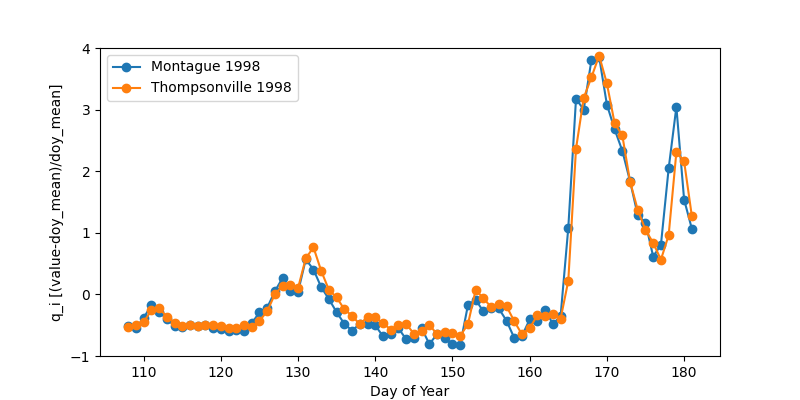

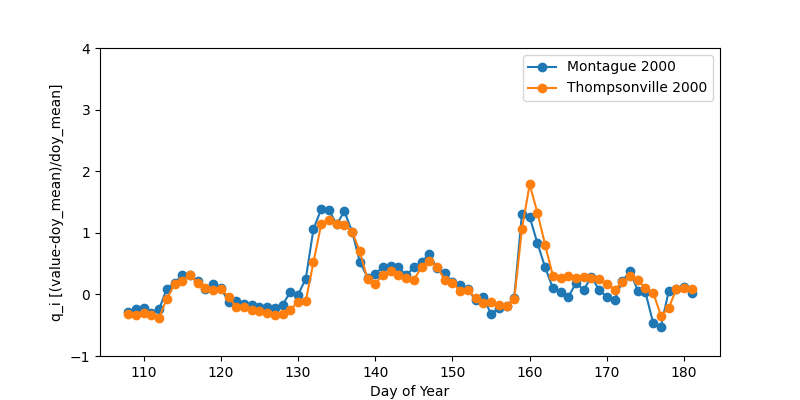

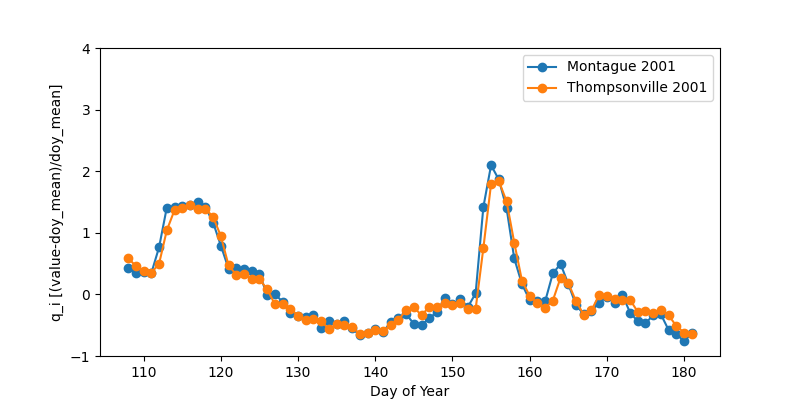

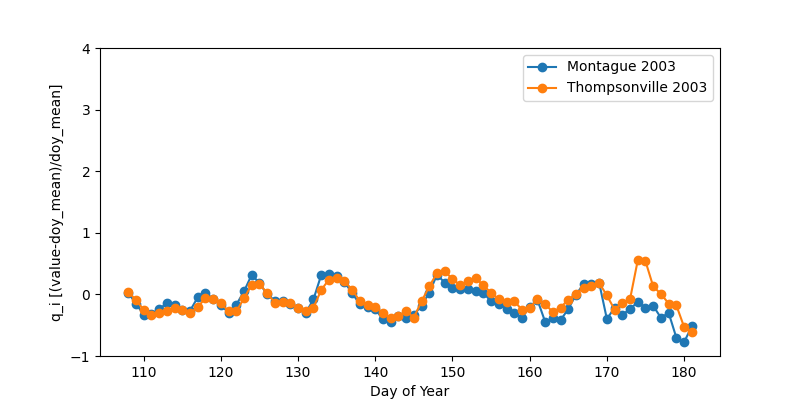

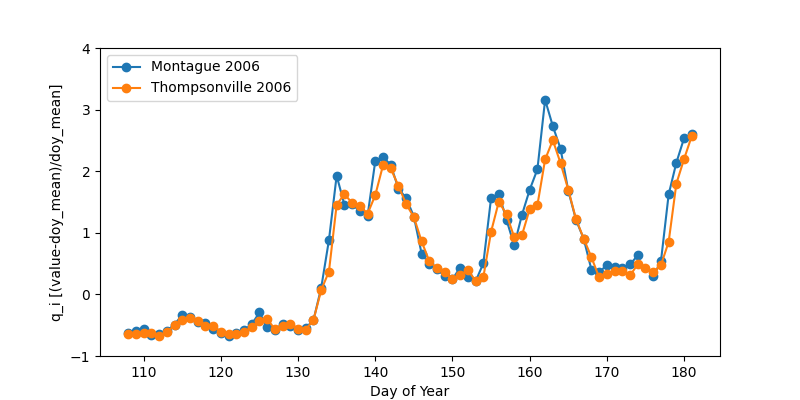

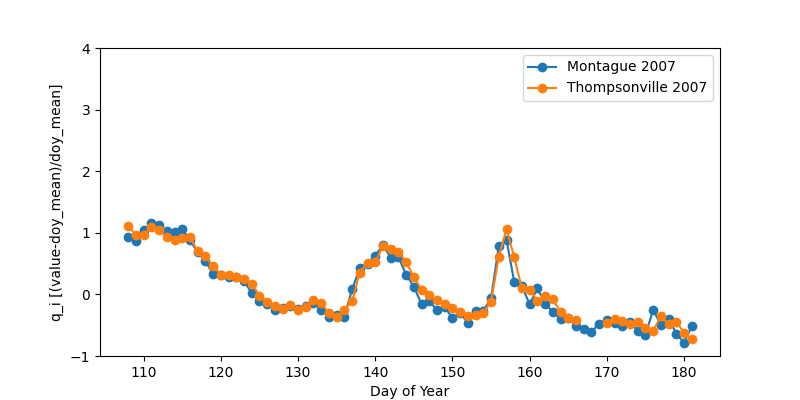

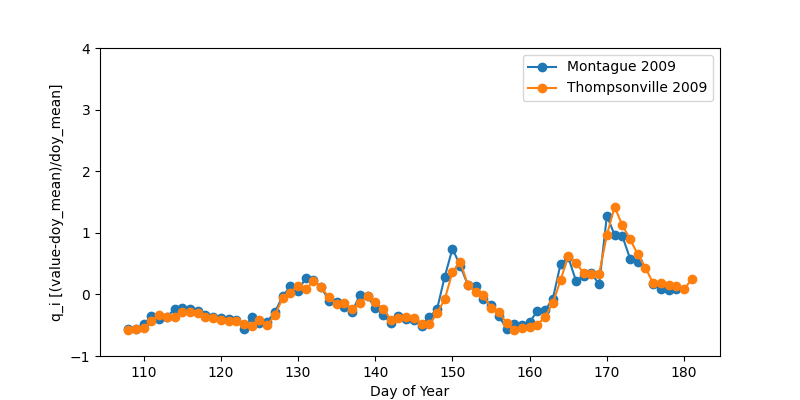

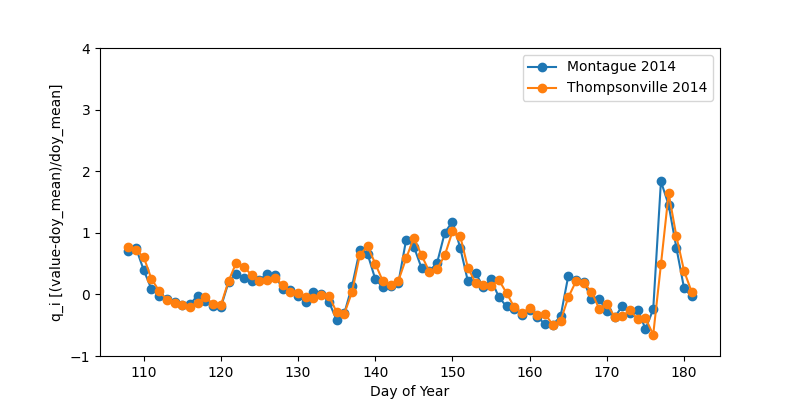

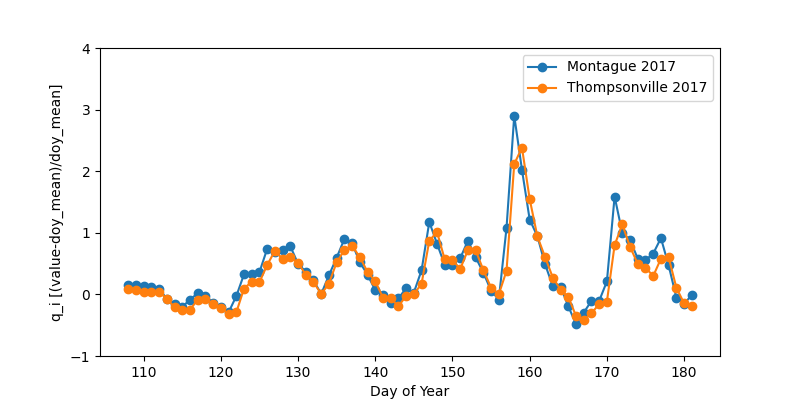

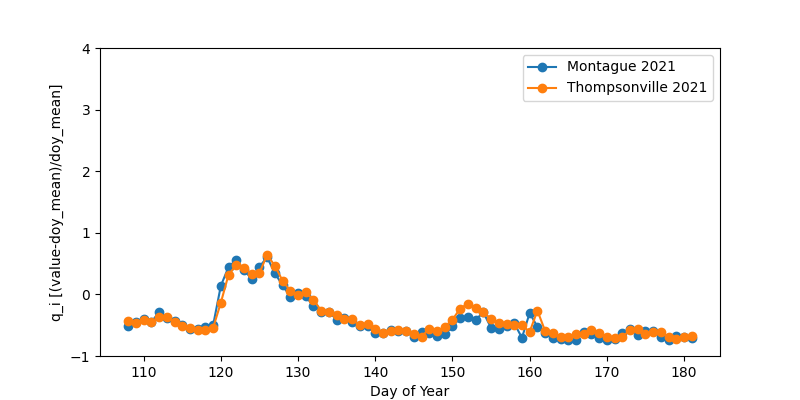

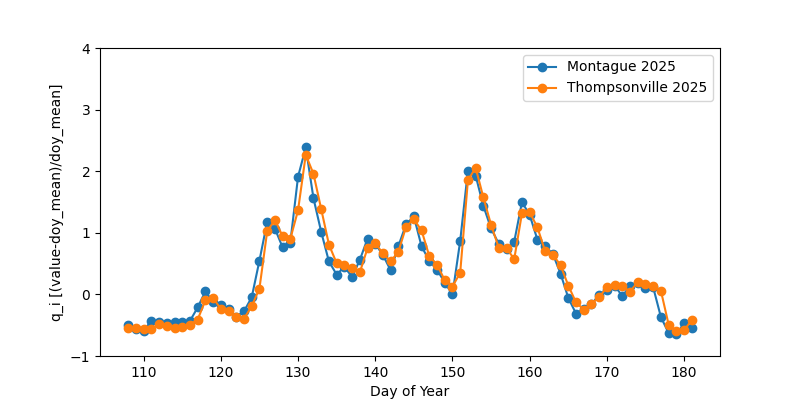

In [35]:
# This is unfinished work trying to correlate Montague to Thompsonville
for year in years_by_target_lag[0]:
    plt.figure(figsize=(8,4))
    plt.plot(m_t["day_of_year"], m_t[year], '-o', label=f"Montague {year}")
    plt.plot(t_t["day_of_year"], t_t[year].shift(0), '-o', label=f"Thompsonville {year}")
    # plt.xticks(m_t["day_of_year"][::6])
    plt.ylim(-1, 4) 
    plt.xlabel("Day of Year")
    plt.ylabel("q_i [(value-doy_mean)/doy_mean]")
    plt.legend()
    plt.show()

In [31]:
# This is unfinished work trying to correlate Montague to Thompsonville
years_by_target_lag = defaultdict(list)
for year in range(1993, 2026):
    if year in m_t.columns and year in t_t.columns:
        mon_thom_corr = m_t[year].corr(t_t[year])
        print(f"Correlation with lag 0, year {year}: {mon_thom_corr}")
        
        lags = range(-5, 5)
        correlations = {}
        
        for lag in lags:
            shifted_t = t_t[year].shift(lag)
            correlations[lag] = m_t.iloc[5:-5].loc[:, year].corr(shifted_t.iloc[5:-5])
        
        target_lag = max(correlations, key=correlations.get)
        years_by_target_lag[target_lag].append(year)
        print(f"T-M Highest correlation lag achieved for year {year}: {target_lag} day(s)")
        print(f"T-M Correlation at lag of {target_lag} day(s) in {year}: {correlations[target_lag]}")
        print("\n --------------------------------------------------------------- \n")
    else:
        print(f"{year} missing from Montague, skipping...\n" if (year not in m_t.columns) else f"{year} missing from Thompsonville, skipping...\n")

Correlation with lag 0, year 1993: 0.9735013210410512
T-M Highest correlation lag achieved for year 1993: -1 day(s)
T-M Correlation at lag of -1 day(s) in 1993: 0.9734044619283108

 --------------------------------------------------------------- 

Correlation with lag 0, year 1994: 0.9376199779844256
T-M Highest correlation lag achieved for year 1994: -1 day(s)
T-M Correlation at lag of -1 day(s) in 1994: 0.9253501786831139

 --------------------------------------------------------------- 

1995 missing from Thompsonville, skipping...

Correlation with lag 0, year 1996: 0.9614637657411351
T-M Highest correlation lag achieved for year 1996: -1 day(s)
T-M Correlation at lag of -1 day(s) in 1996: 0.9749224375014875

 --------------------------------------------------------------- 

Correlation with lag 0, year 1997: 0.9533044686086964
T-M Highest correlation lag achieved for year 1997: -1 day(s)
T-M Correlation at lag of -1 day(s) in 1997: 0.9711612234528383

 ----------------------------

In [32]:
# Next is Holyoke to Middle Haddam... This is also unfinished. What you will need to do is calculate what the lag days will be 
# between these two locations. Then, you will need to calculate each year's linear model using that year's respective tau = lag days